#Task 1: Data Understanding and Visualization:
1. Load and visualize images from a dataset stored in directories, where each subdirec-
tory represents a class. You are expected to write a code:

• Get the list of class directories from the train folder.

• Select one image randomly from each class.

• Display the images in a grid format with two rows using matplotlib.

• Expected Output:

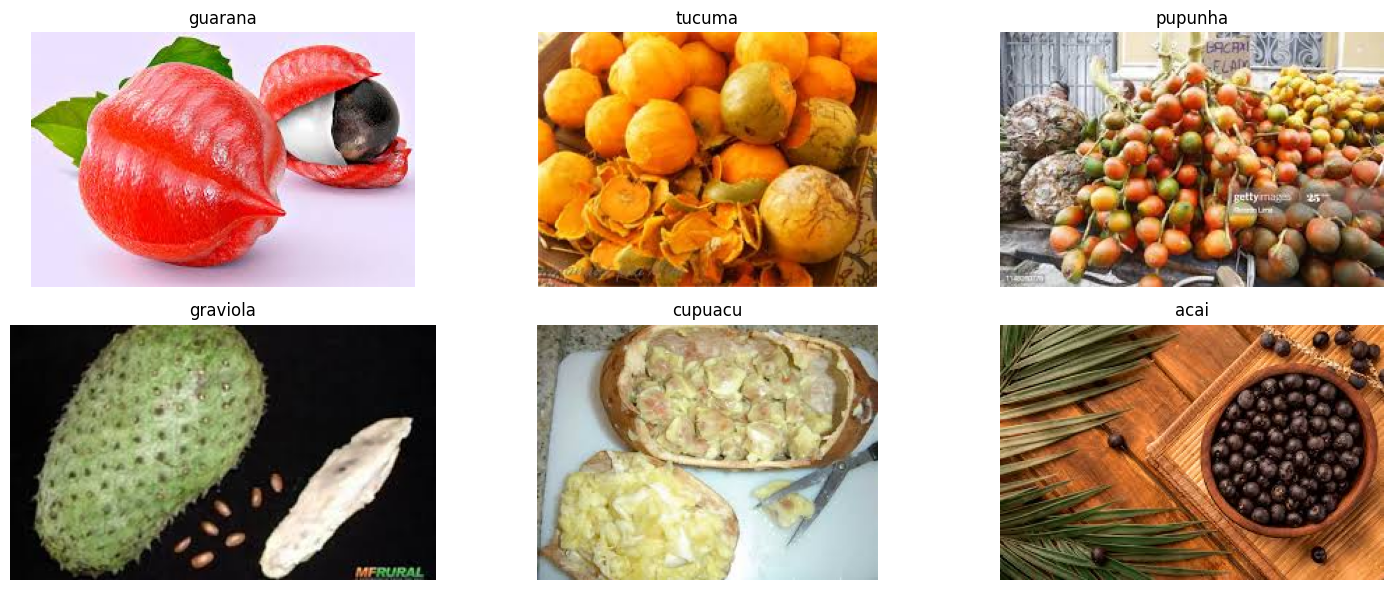

In [1]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report

#dataset
train_dir = "/content/drive/MyDrive/Collage/SEM 6 AI/Week 5/FruitinAmazon/train"

classes = [cls for cls in os.listdir(train_dir)
          if os.path.isdir(os.path.join(train_dir, cls))]

selected_images = []
labels = []
for cls in classes:
    class_path = os.path.join(train_dir, cls)
    images = os.listdir(class_path)

    if len(images) == 0:
        continue

    img_name = random.choice(images)
    img_path = os.path.join(class_path, img_name)

    selected_images.append(img_path)
    labels.append(cls)
# Step 3: Plot images in a grid (2 rows)
num_images = len(selected_images)
cols = (num_images + 1) // 2
plt.figure(figsize=(15, 6))

for i, img_path in enumerate(selected_images):
    img = Image.open(img_path)

    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()




In [2]:
corrupted_images = []

# Iterate through each class subdirectory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            # Try opening and verifying the image
            with Image.open(img_path) as img:
                img.verify()  # checks for corruption

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)

            # Remove corrupted image
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final report
if not corrupted_images:
    print("No Corrupted Images Found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


#Task 2: Loading and Preprocessing Image Data in keras:

In [3]:
import tensorflow as tf
# Define image size and batch size
img_height = 128 # Example image height
img_width = 128 # Example image width
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [4]:
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation

CNN

In [9]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Set number of classes
num_classes = 6   # Corrected based on your dataset

# Input shape (change based on your dataset)
input_shape = (128, 128, 3)

model = models.Sequential()

#Convolutional Layer 1
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=1,
    padding='same',
    activation='relu',
    input_shape=input_shape
))

#Pooling Layer 1
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

#Convolutional Layer 2
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    strides=1,
    padding='same',
    activation='relu'
))

#Pooling Layer 2
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

#Flatten
model.add(layers.Flatten())

#Fully Connected Layers
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(128, activation='relu'))

#Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))
# Model summary
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Compile the Model
**Model Compilation**

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled successfully.")

Model compiled successfully.


#Task 4: Train the Model
**Model Training**

• Use the model.fit() function to train the model. Set the batch size to 16 and the number of epochs
to 250.

• Use val ds for validation.

• Use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model and avoid-
ing overfitting.

In [11]:
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    epochs=250,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping],
    batch_size=16
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.1649 - loss: 1.8966
Epoch 1: val_accuracy improved from None to 0.05556, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.1667 - loss: 1.9388 - val_accuracy: 0.0556 - val_loss: 2.0559
Epoch 2/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2109 - loss: 1.7027
Epoch 2: val_accuracy improved from 0.05556 to 0.38889, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 163ms/step - accuracy: 0.2083 - loss: 1.6759 - val_accuracy: 0.3889 - val_loss: 1.5856
Epoch 3/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6484 - loss: 1.4319 
Epoch 3: val_accuracy improved from 0.38889 to 0.66667, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - accuracy: 0.5972 - loss: 1.4117 - val_accuracy: 0.6667 - val_loss: 1.2872
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7448 - loss: 1.1250 
Epoch 4: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.7500 - loss: 1.1122 - val_accuracy: 0.2222 - val_loss: 1.4044
Epoch 5/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.6953 - loss: 0.8666
Epoch 5: val_accuracy did not improve from 0.66667
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.6806 - loss: 0.8909 - val_accuracy: 0.6111 - val_loss: 0.9628
Epoch 6/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.7891 - loss: 0.6391
Epoch 6: val_accuracy improved from 0.66667 to 0.77778, saving model to best_model.h5



Epoch 6: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 0.7500 - loss: 0.6777 - val_accuracy: 0.7778 - val_loss: 0.7391
Epoch 7/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.9141 - loss: 0.3890
Epoch 7: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8889 - loss: 0.4366 - val_accuracy: 0.7222 - val_loss: 1.0200
Epoch 8/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8906 - loss: 0.3499 
Epoch 8: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8333 - loss: 0.4210 - val_accuracy: 0.5000 - val_loss: 1.4759
Epoch 9/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8984 - loss: 0.3442
Epoch 9: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8611 - loss: 0.3754 - val_accuracy: 0.4444 - val_loss: 0.8589
Epoch 10/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.8047 - loss: 0.378


Epoch 10: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.8056 - loss: 0.3872 - val_accuracy: 0.8889 - val_loss: 0.3957
Epoch 11/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.9453 - loss: 0.2160 
Epoch 11: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9444 - loss: 0.2061 - val_accuracy: 0.8333 - val_loss: 1.0080
Epoch 12/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.9766 - loss: 0.1705 
Epoch 12: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.9722 - loss: 0.1766 - val_accuracy: 0.7778 - val_loss: 0.6659
Epoch 13/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.9766 - loss: 0.1135
Epoch 13: val_accuracy improved from 0.88889 to 0.94444, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9861 - loss: 0.1049 - val_accuracy: 0.9444 - val_loss: 0.2313
Epoch 14/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9844 - loss: 0.0949
Epoch 14: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9722 - loss: 0.1198 - val_accuracy: 0.9444 - val_loss: 0.1676
Epoch 15/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 1.0000 - loss: 0.0549 
Epoch 15: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 1.0000 - loss: 0.0508 - val_accuracy: 0.8889 - val_loss: 0.2621
Epoch 16/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.0548 
Epoch 16: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 1.0000 - loss: 0.0506 - val_accuracy: 0.8333 - val_loss: 0.3925
Epoch 17/250
2/3 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 1.0000 - loss

#Task 5: Evaluate the Model
**Model Evaluation**

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [14]:
test_dir = "/content/drive/MyDrive/Collage/SEM 6 AI/Week 5/FruitinAmazon/train"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False   # VERY IMPORTANT for correct evaluation
)

Found 90 files belonging to 6 classes.


In [15]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.8667 - loss: 64.2353

Test Loss:     64.2353
Test Accuracy: 0.8667


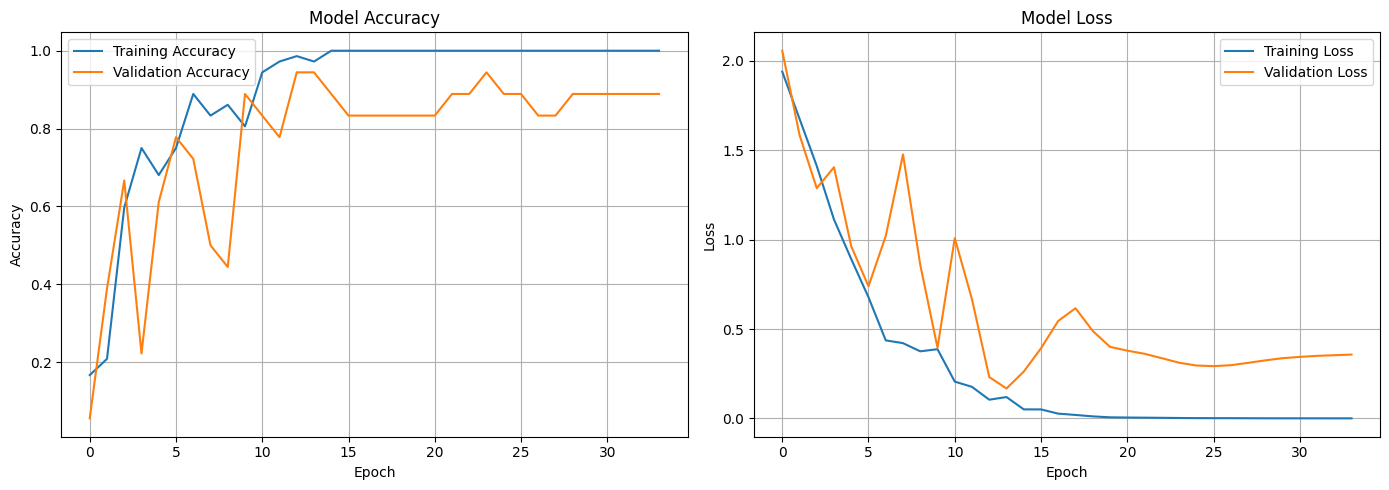

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss
ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


#Task 6: Save and Load the Model
**Model Saving and Loading**

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [17]:
# Save
model.save('/content/drive/MyDrive/Collage/SEM 6 AI/Week 5/fruit_classifier_cnn.h5')
print("Model saved to 'fruit_classifier_cnn.h5'")

# Load
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/Collage/SEM 6 AI/Week 5/fruit_classifier_cnn.h5')
print("Model loaded successfully.")

# Re-evaluate loaded model
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)
print(f"\nLoaded Model — Test Loss:     {loaded_loss:.4f}")
print(f"Loaded Model — Test Accuracy: {loaded_acc:.4f}")

Model saved to 'fruit_classifier_cnn.h5'
Model loaded successfully.
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8667 - loss: 64.2353

Loaded Model — Test Loss:     64.2353
Loaded Model — Test Accuracy: 0.8667


#Task 7: Predictions and Classification Report
**Making Predictions**

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

• Also use from sklearn.metrics import classification report to report the Classification
Report of your Model Performance.

In [18]:
# Collect all predictions and true labels from the test set
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
class_names = classes

# Classification Report
print("Classification Report")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report
              precision    recall  f1-score   support

     guarana       0.94      1.00      0.97        15
      tucuma       0.93      0.87      0.90        15
     pupunha       1.00      0.80      0.89        15
    graviola       0.92      0.80      0.86        15
     cupuacu       0.85      0.73      0.79        15
        acai       0.68      1.00      0.81        15

    accuracy                           0.87        90
   macro avg       0.89      0.87      0.87        90
weighted avg       0.89      0.87      0.87        90

